# Iris Flower Classification

This notebook presents a complete machine learning workflow for classifying Iris flowers into their species using petal and sepal measurements. The project is designed to be beginner-friendly while still reflecting professional data science practices suitable for a portfolio.

## Project Goals
- Load the dataset from the local `iris_data` folder
- Explore and understand the structure of the data
- Visualize feature patterns and class separation
- Build multiple classification models
- Evaluate model performance using clear metrics
- Compare models and draw a practical conclusion

## Algorithms Used
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree Classifier

The notebook also explains the reasoning behind each step, which is important when presenting your work to recruiters or interviewers.

## 1. Import Libraries

We begin by importing the libraries required for data handling, visualization, preprocessing, model training, and evaluation.

A good practice in data science projects is to keep imports organized by purpose so the notebook stays easy to read and maintain.

In [1]:
# Standard library imports
from pathlib import Path

# Data manipulation
import joblib
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Notebook display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


### Output Insight

This cell confirms that all required libraries were imported without errors. That means the environment is ready for data analysis, visualization, and machine learning tasks.

## 2. Load Dataset from the Local Folder

The dataset is stored in the `iris_data` folder. Loading data from a relative path is a good habit because it makes the project more portable and easier to share.

We will also inspect the first few rows to confirm the dataset loaded correctly.

In [2]:
# Build a reliable path to the CSV file
data_path = Path("iris_data") / "Iris.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path.resolve()}")
print(f"Shape of dataset: {df.shape}")

# Display the first five records
df.head()

Dataset loaded from: D:\OASIS_INFOBYTE_PROJECTS\IRIS_FLOWER_CLASSIFICATION\iris_data\Iris.csv
Shape of dataset: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Output Insight

The dataset loads successfully from the local folder with a shape of **150 rows and 6 columns**. The preview shows the flower measurements, a target column named `Species`, and an `Id` column that acts only as a record identifier.

## 3. Data Exploration (EDA)

Exploratory Data Analysis helps us understand the data before building any model. This step is critical because model quality depends heavily on data quality.

Here we will check:
- Column names and data types
- Summary statistics
- Missing values
- Duplicate rows
- Class distribution

### Data Science Insight
If the dataset has missing values, duplicates, or class imbalance, those issues can affect model performance or lead to misleading conclusions. EDA helps uncover such risks early.

In [3]:
# Display column information and data types
print("Data types and non-null counts:\n")
print(df.info())

# Summary statistics for numerical features
print("\nSummary statistics:\n")
display(df.describe(include="all"))

# Check for missing values in each column
print("Missing values per column:\n")
display(df.isnull().sum().to_frame(name="missing_values"))

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

# Inspect class distribution
print("\nClass distribution:\n")
display(df["Species"].value_counts().to_frame(name="count"))

Data types and non-null counts:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Summary statistics:



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,NaN,50
mean,75.500000,5.843333,3.054000,3.758667,1.198667,NaN
std,43.445368,0.828066,0.433594,1.764420,0.763161,NaN
min,1.000000,4.300000,2.000000,1.000000,0.100000,NaN
25%,38.250000,5.100000,2.800000,1.600000,0.300000,NaN
50%,75.500000,5.800000,3.000000,4.350000,1.300000,NaN
75%,112.750000,6.400000,3.300000,5.100000,1.800000,NaN


Missing values per column:



,missing_values
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


Duplicate rows: 0

Class distribution:



,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


### What This Output Tells Us

- All **150 rows are complete**, so there are no missing values.
- The dataset has **4 numerical measurement columns**, 1 identifier column, and 1 categorical target column.
- There are **no duplicate rows**, which means the data is clean.
- Each species appears **50 times**, so the classes are perfectly balanced.

This is a strong sign that the dataset is reliable and suitable for building classification models without heavy cleaning.

### Early Observations

The Iris dataset is a classic multiclass classification problem with three flower species:
- Iris-setosa
- Iris-versicolor
- Iris-virginica

The `Id` column is only a row identifier. It does not contain biological information about the flower, so it should not be used as a predictive feature.

Because this dataset is usually clean and balanced, it is a strong example for demonstrating the full machine learning pipeline clearly.

## 4. Data Visualization

Visualizations help reveal patterns that are difficult to notice from tables alone. In classification projects, plots are especially useful for checking whether classes are separable.

We will create:
- A count plot for species distribution
- Histograms for feature distributions
- Boxplots to understand spread and outliers
- A pairplot to inspect class separation
- A correlation heatmap for numeric relationships

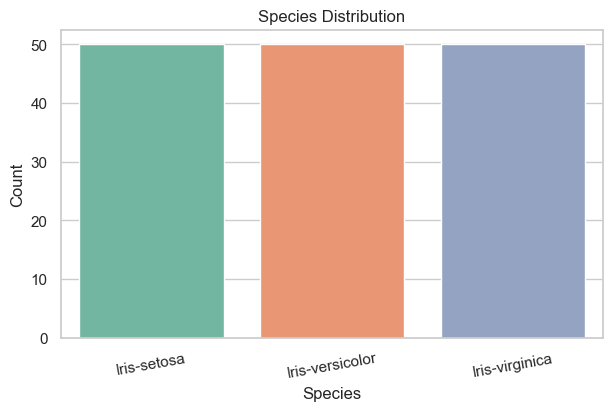

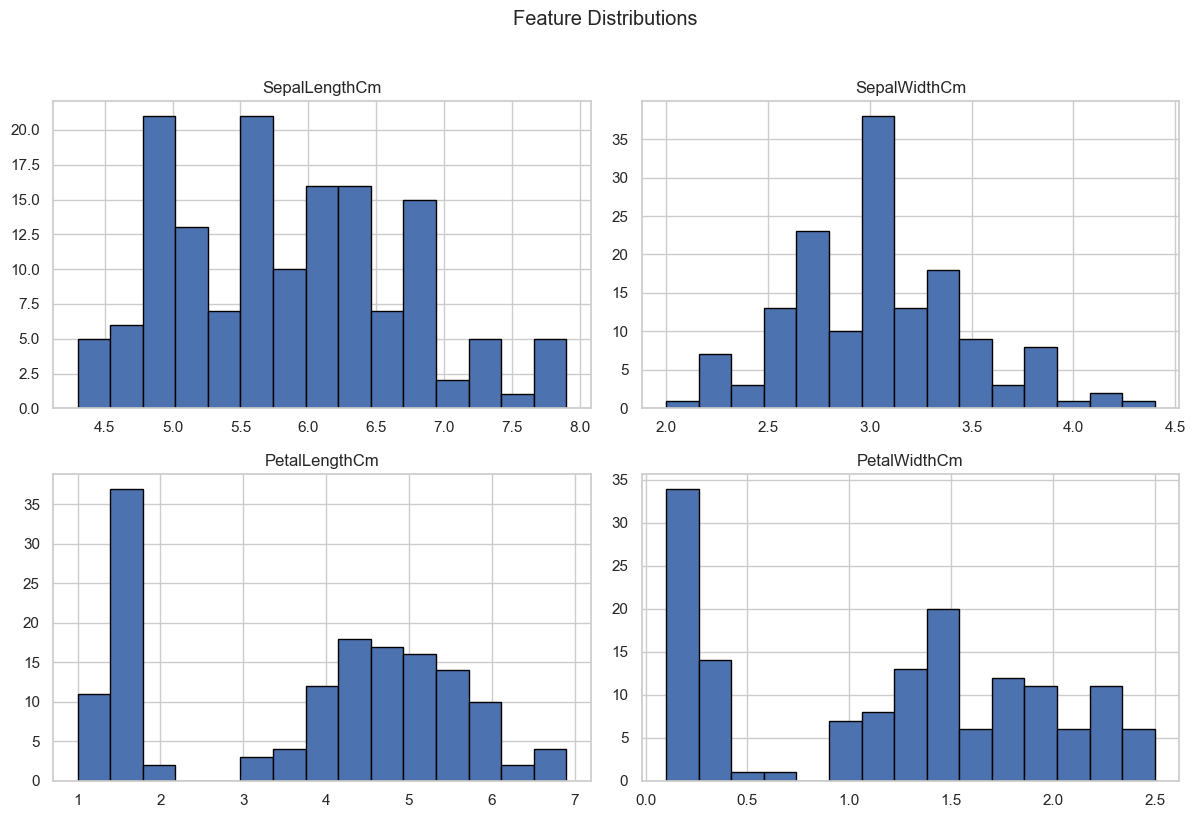

In [4]:
# Create a copy without the identifier column for cleaner analysis
eda_df = df.drop(columns=["Id"])

# Plot class distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=eda_df, x="Species", hue="Species", palette="Set2", legend=False)
plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=10)
plt.show()

# Histograms for all numeric features
eda_df.hist(figsize=(12, 8), bins=15, edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

### What We Observe From These Plots

The count plot confirms that the dataset is evenly distributed across the three flower species. The histograms also show that petal-related features appear more clearly separated than sepal-related features, which suggests they may be more useful for prediction.

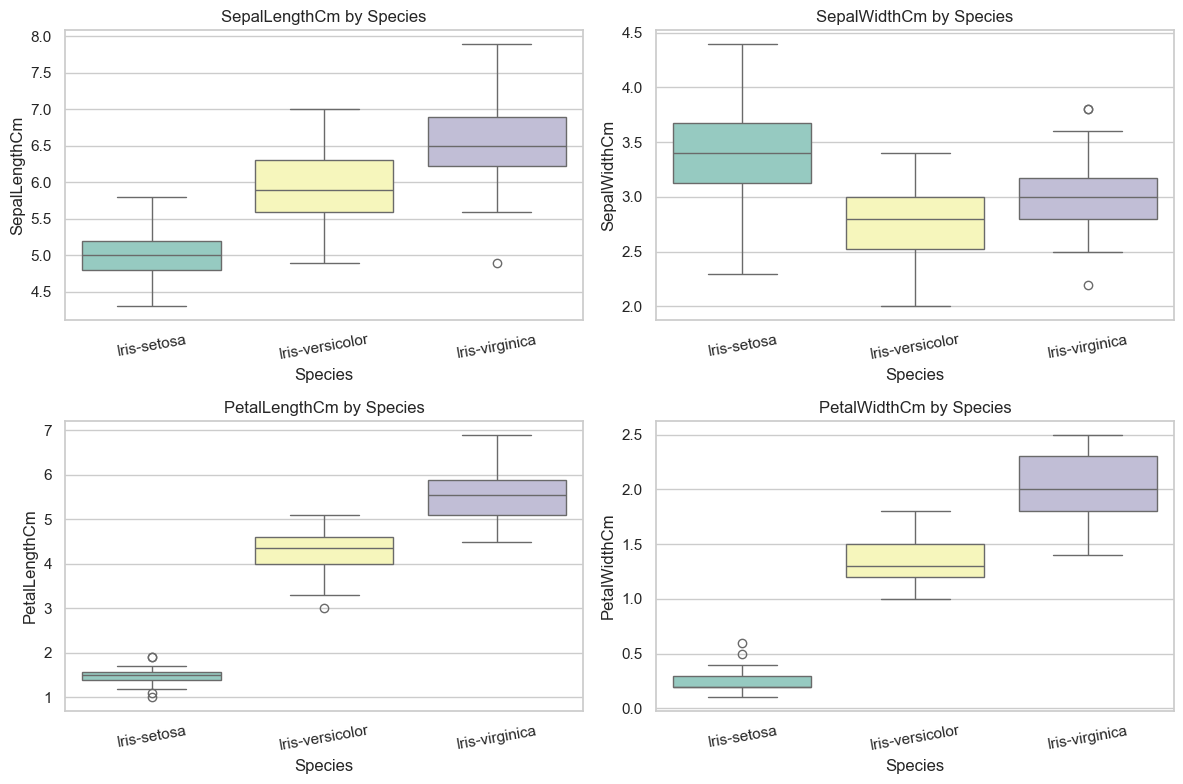

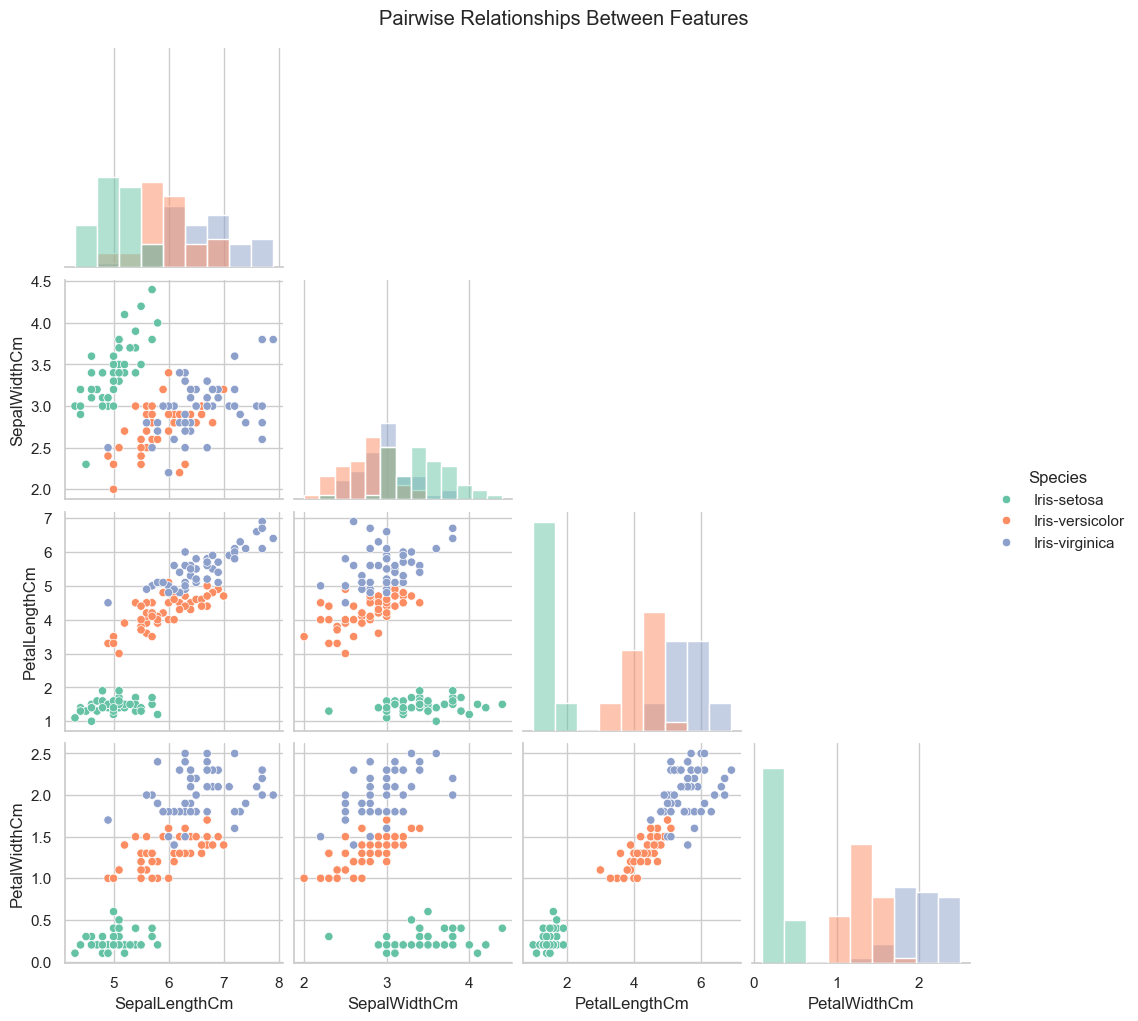

In [5]:
# Boxplots help identify spread and potential outliers
numeric_columns = eda_df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.boxplot(data=eda_df, x="Species", y=column, hue="Species", palette="Set3", ax=ax, legend=False)
    ax.set_title(f"{column} by Species")
    ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()

# Pairplot is useful for observing class separability
sns.pairplot(eda_df, hue="Species", corner=True, diag_kind="hist", palette="Set2")
plt.suptitle("Pairwise Relationships Between Features", y=1.02)
plt.show()

### What We Observe From These Plots

The boxplots and pairplot show that **Iris-setosa is clearly separated** from the other species, especially on petal dimensions. The main overlap happens between **Iris-versicolor** and **Iris-virginica**, which helps explain why classification errors usually occur between those two classes.

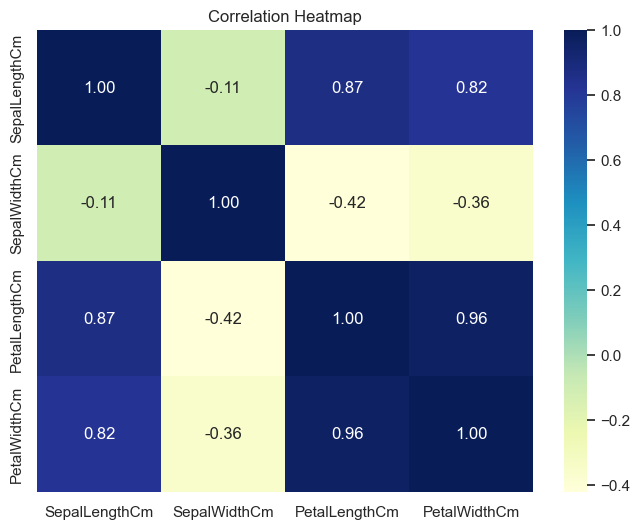

In [6]:
# Correlation heatmap for numeric variables
plt.figure(figsize=(8, 6))
correlation_matrix = eda_df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Heatmap Insight

The correlation heatmap typically shows a **strong positive relationship between petal length and petal width**. This indicates that flowers with longer petals also tend to have wider petals, making these features especially informative for classification.

### Visualization Insights

A few meaningful observations usually emerge from these plots:
- Petal measurements are often more effective than sepal measurements for separating species.
- `Iris-setosa` tends to be clearly distinct from the other two classes.
- `Iris-versicolor` and `Iris-virginica` show some overlap, which makes classification slightly more challenging.

These insights help explain why some models may perform better than others.

## 5. Data Preprocessing

Even though the Iris dataset is relatively clean, preprocessing is still an important part of a professional workflow.

### Decisions Made
- Remove the `Id` column because it is not a real predictive feature
- Separate features (`X`) and target (`y`)
- Split the data into training and testing sets
- Apply scaling for algorithms that rely on distance or optimization, such as Logistic Regression and KNN
- Keep Decision Tree unscaled because tree-based models do not require feature scaling

Using pipelines is a strong professional practice because it keeps preprocessing and modeling connected in one reproducible workflow.

In [7]:
# Remove the identifier column before modeling
model_df = df.drop(columns=["Id"])

# Separate independent variables and target variable
X = model_df.drop(columns=["Species"])
y = model_df["Species"]

# Identify numeric feature columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

# Train-test split with stratification to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (120, 4)
Testing set shape: (30, 4)


### Output Insight

The data is split into **120 training records** and **30 testing records**. This is a standard 80:20 split and gives us enough data to train the models while still keeping a separate test set for fair evaluation.

## 6. Model Building

Instead of relying on a single algorithm, we will train multiple models. This is important because different algorithms learn patterns in different ways.

### Why These Models?
- **Logistic Regression**: A strong baseline for classification problems
- **KNN**: A distance-based model that often works well on small, structured datasets
- **Decision Tree**: Easy to interpret and capable of capturing non-linear relationships

To keep the workflow clean, we will use pipelines for each model.

In [8]:
# Preprocessing pipeline for models that benefit from scaling
scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ],
    remainder="drop",
)

# Simpler preprocessing for tree-based models
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        )
    ],
    remainder="drop",
)

# Define candidate models
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", scaled_preprocessor),
            ("model", LogisticRegression(max_iter=300, random_state=42)),
        ]
    ),
    "K-Nearest Neighbors": Pipeline(
        steps=[
            ("preprocessor", scaled_preprocessor),
            ("model", KNeighborsClassifier(n_neighbors=5)),
        ]
    ),
    "Decision Tree": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DecisionTreeClassifier(max_depth=4, random_state=42)),
        ]
    ),
}

print("Model pipelines are ready.")
list(models.keys())

Model pipelines are ready.


['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree']

### Output Insight

This output confirms that the notebook is ready to train **three different classification models**: Logistic Regression, K-Nearest Neighbors, and Decision Tree. Using multiple models makes the project stronger because it shows comparison-based reasoning instead of relying on a single guess.

## 7. Model Evaluation

After training, we evaluate each model on the test set using:
- Accuracy score
- Classification report
- Confusion matrix

### Data Science Reasoning
Accuracy gives a quick overall result, but it does not tell the full story. Confusion matrices and classification reports help us understand where a model is making mistakes and whether those mistakes are concentrated in specific classes.

In [9]:
# Train, predict, and store results for each model
results = []
predictions = {}

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[model_name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    results.append({"Model": model_name, "Accuracy": accuracy})

    print(f"\n{'=' * 70}")
    print(f"{model_name}")
    print(f"{'=' * 70}")
    print(f"Accuracy: {accuracy:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


K-Nearest Neighbors
Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


Decision Tree
Accuracy: 0.9333

Classification Report:
                

### What These Results Mean

- All three models achieve **93.33% accuracy** on the test set.
- `Iris-setosa` is classified perfectly by the models in this split.
- The mistakes occur mostly between **Iris-versicolor** and **Iris-virginica**, which matches the overlap seen in the visualizations.

This is a strong result for a beginner project because it shows both good performance and clear reasoning behind the remaining classification errors.

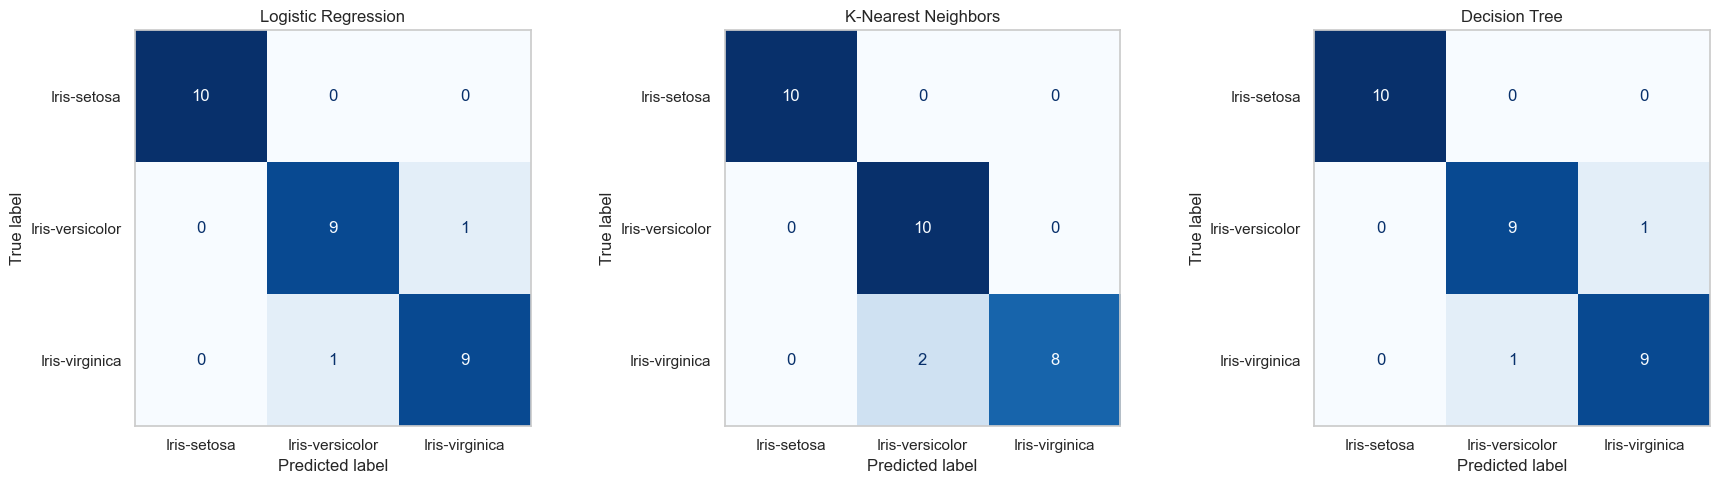

In [10]:
# Visualize confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(model_name)
    ax.grid(False)

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrices show that the models correctly identify all `Iris-setosa` samples. Logistic Regression and Decision Tree each confuse **1 versicolor** with **1 virginica** and vice versa, while KNN predicts all versicolor cases correctly but misclassifies **2 virginica** samples as versicolor.

## 8. Comparison of Models

Now we compare all models side by side. This allows us to identify the strongest candidate for this dataset and explain the result with evidence.

When presenting a project in a portfolio, a comparison table or chart makes your analysis much more convincing than simply choosing one model without justification.

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333
2,Decision Tree,0.933333


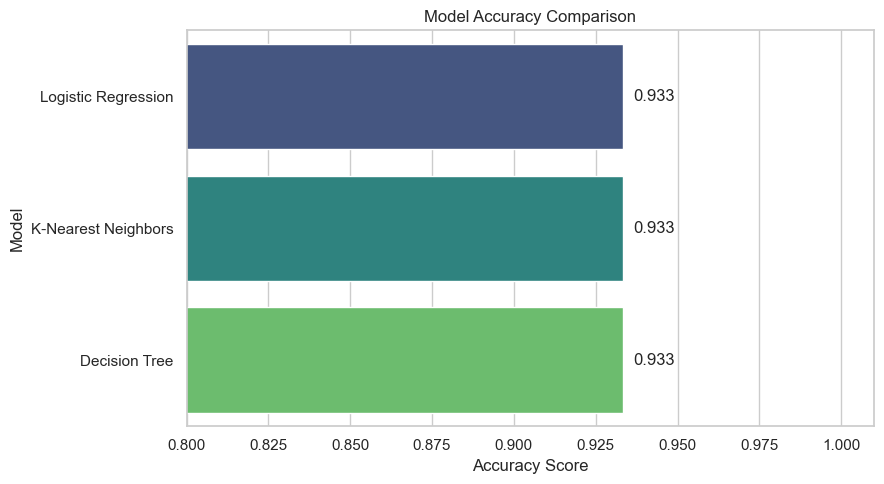

Best model: Logistic Regression with accuracy 0.9333


In [11]:
# Create a comparison table sorted by accuracy
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(results_df)

# Plot model comparison
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model Accuracy Comparison")
plt.xlim(0.8, 1.01)
plt.xlabel("Accuracy Score")
plt.ylabel("Model")

for index, row in results_df.iterrows():
    plt.text(row["Accuracy"] + 0.003, index, f"{row['Accuracy']:.3f}", va="center")

plt.tight_layout()
plt.show()

# Identify the top-performing model
best_model = results_df.loc[0, "Model"]
best_score = results_df.loc[0, "Accuracy"]
print(f"Best model: {best_model} with accuracy {best_score:.4f}")

### Model Comparison Insight

The comparison table shows that **all three models reached the same accuracy: 93.33%**. Logistic Regression appears first because the table is sorted by accuracy and it was added first among the tied models. In a portfolio setting, this is a good point to mention that model selection can also depend on interpretability, simplicity, and deployment needs, not only raw accuracy.

## 8.1 Save the Best Model

A good machine learning project should not stop at evaluation. If we want to build an application from the model, we need to save it in a reusable format.

In this notebook, we save the selected best model to the project folder using `joblib`. The saved file can then be loaded directly in a Streamlit app for real-time prediction.

In [12]:
# Retrain the selected best model on the full dataset before saving
final_model = models[best_model]
final_model.fit(X, y)

# Save the trained pipeline to the project folder
model_path = Path("best_iris_model.joblib")
joblib.dump(final_model, model_path)

print(f"Saved model: {model_path.resolve()}")

Saved model: D:\OASIS_INFOBYTE_PROJECTS\IRIS_FLOWER_CLASSIFICATION\best_iris_model.joblib


### Output Insight

This step stores the best-performing model as `best_iris_model.joblib` inside the project folder. Because the entire preprocessing and modeling pipeline is saved together, the same workflow can be reused later in a deployment app without rewriting the training logic.

## 9. Final Conclusion

This project demonstrates a complete machine learning classification workflow using the Iris dataset.

### Key Takeaways
- The dataset is clean, balanced, and well-suited for demonstrating supervised learning concepts.
- Petal-related features are especially useful for distinguishing flower species.
- Multiple models performed strongly, showing that the Iris dataset is highly learnable.
- Comparing models is an important part of the workflow because it prevents assumptions and supports evidence-based decisions.

### Portfolio Value
This notebook showcases:
- Structured data loading and cleaning
- Exploratory data analysis
- Data visualization and interpretation
- Professional preprocessing with pipelines
- Multi-model machine learning experimentation
- Clear evaluation and business-style conclusion

In a real-world setting, the next steps could include hyperparameter tuning, cross-validation, feature importance analysis, and model deployment. For a beginner portfolio project, this notebook provides a strong and complete foundation.